In [1]:
# Cellule 1 : Imports et configuration
%load_ext autoreload
%autoreload 2

import pandas as pd

# Import des classe et fonctions personnalisées
from tools.OI_class_v2 import OI_DataProcessor
from tools.OI_utils import extract_xls,analyser_correlation_croisee

# Configuration de l'affichage pour voir toutes les colonnes
pd.set_option('display.max_columns', None)

In [2]:
tags = [
        {'tag':'WQ33222VA', 'nom':'Ester','info':'Totalisation du Peson Acetate/Propionate' },
        {'tag':'3340_type', 'nom':'A/P','info':'Acetate ou Propionate' },
        {'tag':'CTY_ACV43A_Teneur Vit. A (UV)', 'nom':'Acetate_UV','info':'ACV43A teneur en acetate'},
        {'tag':'CTY_A3340FGB_Teneur arr. Vit. A (UV)', 'nom':'Propionate_UV', 'info':'A3340FGB teneur en propionate'},
        {'tag':'PU3310VA_Sign','nom':'PU3310','info':'signature du PU3310'},
        {'tag':'PU3320VA_Sign','nom':'PU3320','info':'signature du PU3320'},
        {'tag':'PU3340VA_Sign','nom':'PU3340','info':'signature du PU3340'},
        {'tag':'FQ32202VA_UV','nom':'Hexane','info':'VA diluée dans de l\'hexane'},
        {'tag':'CTY_A3230A_Teneur en rétinol', 'nom':'Retinol','info':'A3230A teneur en rétinol lavé'},
        {'tag':'LI33203VA','nom':'R33020','info':'niveau du R33020'},
        {'tag':'LI33218VA','nom':'R33022','info':'niveau du R33022'},
        {'tag':'LI33225VA','nom':'R33061','info':'niveau du R33061'},
        {'tag':'WI33222VA','nom':'R33060','info':'peson du R33060'},
    ]

In [3]:
batchs = [
    {'tag':'PU3310', 'min':540, 'max':710, 'value':'Hexane', 'uv':'Retinol', 'scale':1/825/100., 'default':2.71, 'cond':None, 'val_cond': None},
    {'tag':'PU3310', 'min':710, 'max':2320, 'value':None, 'uv':None, 'scale':2.71, 'default':0, 'cond':None, 'val_cond':None},
    {'tag':'PU3320', 'min':430, 'max':2020, 'value':None, 'uv':None, 'scale':2.71, 'default':0, 'cond':None, 'val_cond':None},
    {'tag':'PU3340', 'min':0, 'max':710, 'value':'R33060', 'uv':None, 'scale':0.95, 'default':0, 'cond':'A/P', 'val_cond':[1/344,1/359]},
]

In [4]:
continus = [
    {'tag':'R33020', 'min': 14,  'epalage': [[28.62,21.22,3.866,-0.0983], [-228.84,74.557]], 'uv':'Retinol', 'scale':1/100., 'cond':'A/P', 'val_cond':[1/344,1/359] },
    {'tag':'R33022', 'min': 14,  'epalage': [[6.25,5.4525,0.898,-0.0256], [-35,97,16.039]], 'uv':'Retinol', 'scale':1/100., 'cond':'A/P', 'val_cond':[1/344,1/359] },
    {'tag':'R33061', 'min': 18,  'epalage': [[0.69,0.72,0.296,-0.0059], [-30.03,5.836]], 'uv':None, 'scale':0.95, 'cond':'A/P', 'val_cond':[1/344,1/359] },
]

In [5]:
# Initialisation
processor = OI_DataProcessor(
    url_base = 'https://oianalytics-100.optimistik.fr/api/oianalytics/time-values/query?',
    tags_other = [],
    tags_selected = tags,
    start='2026-05-12',
    end='2026-05-14',
    interval='PT20M',
    verbose=False
)

# Charger les données
processor.merge()

# Appliquer des filtres (chaînage possible)
processor.filtering(
    tag=['Ester'],
    min_val=[0],
    max_val=[10_000_000],
    na=['Ester']
)

# Ajouter des colonnes
processor.ajoute_calcul('Ester','A/P','Acetate_UV','Propionate_UV',1e-9,'cumul')
#processor.ajoute_batch(batchs[3],'batchs')
#processor.ajoute_continus(continus[0],'continus')
processor.ajoute_all_batchs(batchs,'batchs')
processor.ajoute_all_continus(continus,'continus')
#processor.ajoute_cumul('A1000M_Poids', 'A1000M_UV_Auto', 1000, 'Cumul_UV')
#processor.ajouter_moyennes_glissantes_ponderee('A1000M_Poids', 'A1000M_UV_Auto', 'A1000M_Moyenne_UV', window=15)
#processor.ajouter_moyennes_glissantes('Acetate_UV', 'Acetate_Moyenne_UV', window=15)

# Afficher les infos finales
processor.info()
#processor.data

INFORMATIONS DataProcessor
URL de base       : https://oianalytics-100.optimistik.fr/api/oianalytics/time-values/query?
Tags autres       : []
Tags sélectionnés : [{'tag': 'WQ33222VA', 'nom': 'Ester', 'info': 'Totalisation du Peson Acetate/Propionate'}, {'tag': '3340_type', 'nom': 'A/P', 'info': 'Acetate ou Propionate'}, {'tag': 'CTY_ACV43A_Teneur Vit. A (UV)', 'nom': 'Acetate_UV', 'info': 'ACV43A teneur en acetate'}, {'tag': 'CTY_A3340FGB_Teneur arr. Vit. A (UV)', 'nom': 'Propionate_UV', 'info': 'A3340FGB teneur en propionate'}, {'tag': 'PU3310VA_Sign', 'nom': 'PU3310', 'info': 'signature du PU3310'}, {'tag': 'PU3320VA_Sign', 'nom': 'PU3320', 'info': 'signature du PU3320'}, {'tag': 'PU3340VA_Sign', 'nom': 'PU3340', 'info': 'signature du PU3340'}, {'tag': 'FQ32202VA_UV', 'nom': 'Hexane', 'info': "VA diluée dans de l'hexane"}, {'tag': 'CTY_A3230A_Teneur en rétinol', 'nom': 'Retinol', 'info': 'A3230A teneur en rétinol lavé'}, {'tag': 'LI33203VA', 'nom': 'R33020', 'info': 'niveau du R3302

In [25]:
# 1. On veut changer de date ?
processor.start = '2026-01-01'
processor.end = '2026-12-31'

# 2. On recalcule TOUT (merge + filtres + cumul) en une commande
processor.recalculate()

# 3. On vérifie le pipeline
processor.show_pipeline()
processor.info()
processor.data.describe()


--- PIPELINE ACTUEL ---
1. filtering | Args: () | Kwargs: {'tag': ['Ester'], 'min_val': [0], 'max_val': [10000000], 'na': ['Ester']}
2. ajoute_calcul | Args: ('Ester', 'A/P', 'Acetate_UV', 'Propionate_UV', 1e-09, 'cumul') | Kwargs: {}
3. ajoute_all_batchs | Args: ([{'tag': 'PU3310', 'min': 540, 'max': 710, 'value': 'Hexane', 'uv': 'Retinol', 'scale': 1.2121212121212122e-05, 'default': 2.71, 'cond': None, 'val_cond': None}, {'tag': 'PU3310', 'min': 710, 'max': 2320, 'value': None, 'uv': None, 'scale': 2.71, 'default': 0, 'cond': None, 'val_cond': None}, {'tag': 'PU3320', 'min': 430, 'max': 2020, 'value': None, 'uv': None, 'scale': 2.71, 'default': 0, 'cond': None, 'val_cond': None}, {'tag': 'PU3340', 'min': 0, 'max': 710, 'value': 'R33060', 'uv': None, 'scale': 0.95, 'default': 0, 'cond': 'A/P', 'val_cond': [0.0029069767441860465, 0.002785515320334262]}], 'batchs') | Kwargs: {}
4. ajoute_all_continus | Args: ([{'tag': 'R33020', 'min': 14, 'epalage': [[28.62, 21.22, 3.866, -0.0983], [-2

,Ester,A/P,Acetate_UV,Propionate_UV,PU3310,PU3320,PU3340,Hexane,Retinol,R33020,R33022,R33061,R33060,cumul,batchs,continus
count,1.058400e+04,10584.000000,1.058400e+04,1.058400e+04,10581.000000,10582.000000,10580.000000,10584.000000,10584.000000,10584.000000,10584.000000,10584.000000,10584.000000,10584.000000,10584.000000,10584.000000
mean,2.442153e+06,0.078564,2.225992e+06,2.284134e+06,1014.638541,943.115008,461.974638,2571.837141,20.795055,45.578027,4.925524,7.198727,683.900345,492.018124,4.640014,2.019476
std,1.380099e+05,0.268940,3.911680e+04,4.926737e+04,600.136547,529.639145,111.620504,1859.803088,0.374165,20.358175,2.407110,11.026569,346.477539,308.682277,2.053956,0.945134
min,2.221310e+06,0.000000,2.078915e+06,2.188000e+06,100.000000,100.000000,313.116667,0.000000,20.000000,-7.918751,-0.695313,-0.337315,6.278194,0.000000,0.000000,0.021466
25%,2.312340e+06,0.000000,2.221983e+06,2.242000e+06,400.000000,400.000000,410.000000,0.000000,20.600000,23.987310,3.398876,2.196213,422.605516,202.180435,3.467014,0.998463
50%,2.423810e+06,0.000000,2.230864e+06,2.314000e+06,1310.000000,1113.858333,410.000000,3932.160000,20.800000,44.866429,5.930773,2.894995,680.080065,449.269022,4.818357,2.024976
75%,2.563920e+06,0.000000,2.245768e+06,2.314000e+06,1310.000000,1304.603125,410.000000,4038.500000,21.200000,64.434423,6.478707,4.027957,941.790362,764.391479,6.084583,2.891590
max,2.698290e+06,1.000000,2.325113e+06,2.626000e+06,2320.033333,2249.987500,810.000000,4836.070000,21.200000,91.504357,12.239069,68.457970,1321.036235,1067.339758,9.000560,4.031430


In [26]:
processor.data.batchs.value_counts()

batchs
2.710000    661
5.420000    439
0.000000    118
0.052266     11
2.739127      7
           ... 
5.546879      1
6.044706      1
3.335966      1
3.716656      1
6.258590      1
Name: count, Length: 9318, dtype: int64

In [27]:
nb = processor.data['Ester'].size
ester = (processor.data.iloc[-1]['cumul'] - processor.data.iloc[0]['cumul'])
deltaBatch = processor.data.iloc[-1]['batchs'] - processor.data.iloc[0]['batchs']
deltaContinus = processor.data.iloc[-1]['continus'] - processor.data.iloc[0]['continus']
print(nb, ester + deltaBatch +deltaContinus, ester,  deltaBatch, deltaContinus)
stock_entree = processor.data.iloc[0]['batchs'] + processor.data.iloc[0]['continus']
stock_sortie = processor.data.iloc[-1]['batchs'] + processor.data.iloc[-1]['continus']

print('stock entrée :', stock_entree)
print('stock sortie :', stock_sortie)
print('variation stock :', stock_sortie - stock_entree)
print('Consommation :', ester)
print('production :', deltaBatch + deltaContinus+ ester)

10584 1066.8399079935452 1067.3397583514734 -2.0290597218551794 1.5292093639270743
stock entrée : 6.227412348661154
stock sortie : 5.727561990733049
variation stock : -0.4998503579281053
Consommation : 1067.3397583514734
production : 1066.8399079935452


In [33]:
# Approche 1 : Simple - indexer par jour
jour1 = '2026-05-01 03:00:00'
data_jour1 = processor.data.loc[jour1]
jour2 = '2026-05-28 03:00:00'
data_jour2 = processor.data.loc[jour2]
delta_ester = data_jour2['cumul']-data_jour1['cumul']
delta_batchs = data_jour2['batchs']-data_jour1['batchs']
delta_continus = data_jour2['continus']-data_jour1['continus']
stock_j1 = data_jour1['batchs'] + data_jour1['continus']
stock_j2 = data_jour2['batchs'] + data_jour2['continus']
print('stocks : ', stock_j1, stock_j2)
print(delta_ester, delta_batchs, delta_continus)
print(delta_ester + delta_batchs + delta_continus)
print(processor.data.loc[jour1], processor.data.loc[jour2])

stocks :  10.682372176968178 5.714044446552839
236.0030471329867 -5.125142056686047 0.15681432627070846
231.03471940257134
Ester            2.593880e+06
A/P              0.000000e+00
Acetate_UV       2.230864e+06
Propionate_UV    2.314000e+06
PU3310           1.163900e+03
PU3320           7.746000e+02
PU3340           4.100000e+02
Hexane           1.450575e+03
Retinol          2.080000e+01
R33020           6.468558e+01
R33022           7.243451e+00
R33061           3.647586e+00
R33060           8.745357e+02
cumul            8.313367e+02
batchs           7.835142e+00
continus         2.847230e+00
Name: 2026-05-01 03:00:00+00:00, dtype: float64 Ester            2.698290e+06
A/P              0.000000e+00
Acetate_UV       2.266089e+06
Propionate_UV    2.188000e+06
PU3310           4.000000e+02
PU3320           1.127025e+03
PU3340           7.100000e+02
Hexane           0.000000e+00
Retinol          2.060000e+01
R33020           5.810736e+01
R33022           7.166533e+00
R33061           3.

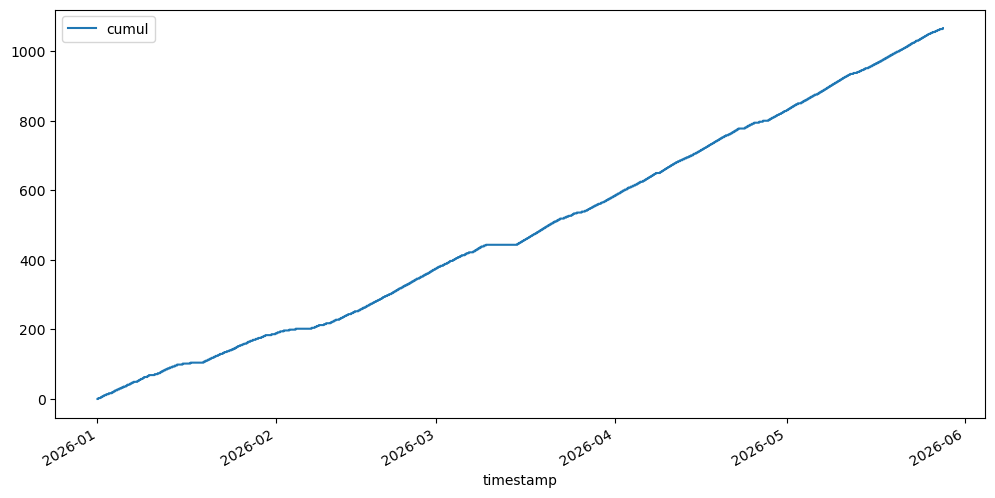

In [34]:
processor.data.plot(y=['cumul'], figsize=(12,6));

In [11]:
def l(v):
    return v*74.557 - 228.84

In [12]:
print( (l(22.22)-l(67.35))/344 * 20.9/100 )

-2.044285752005814
